### 真實資料操作與分析_1: 資料前處理

In [5]:
import pandas as pd
import numpy as np

# 讀取檔案
stock = pd.read_csv('2327.csv', encoding='big5')
stock.head(20)
stock.tail(20)

# 欄位的更名
stock = stock.rename(columns={'證券代碼':'coid', '簡稱':'name', '年月日':'date',
            '開盤價(元)':'open', '最高價(元)':'high', '最低價(元)':'low',
            '收盤價(元)':'close', '成交量(千股)':'volume'})
stock

# 欄位的刪除
stock = stock.drop(columns=['coid', 'name'])
stock

# 時間格式的變更
stock['date'] = pd.to_datetime(stock['date'], format='%Y%m%d')
stock

# 將日期設為索引
stock = stock.set_index('date')
stock.head()

stock.to_csv('2327_Final.csv', encoding='utf8')
stock

,open,high,low,close,volume
date,,,,,
2000-01-04,38.3,38.8,37.5,37.5,75810
2000-01-05,35.2,37.5,35.2,36.2,55597
2000-01-06,36.2,37.4,35.8,36.4,61787
2000-01-07,36.4,37.4,36.4,36.6,57708
2000-01-10,37.2,38.5,36.8,37.8,61759
...,...,...,...,...,...
2026-06-22,1115.0,1120.0,1040.0,1065.0,62351
2026-06-23,1060.0,1085.0,1020.0,1020.0,46353
2026-06-24,1005.0,1075.0,985.0,1050.0,49108


### 真實資料操作與分析_2: 繪製曲線圖和K線圖

In [6]:
# 讀取資料

stock = pd.read_csv('2327_Final.csv', encoding='utf8')
stock.head()

# 時間格式的變更
# 因為原本用read_csv讀進來的檔案的date會變成字串格式，
# 所以我們要轉換成日期格式才能使用時間切片
stock.index = pd.to_datetime(stock.date) # 利用to_datetime對date進行格式轉換
stock = stock.drop(columns=['date']) # 刪除舊有的字串格式的date
stock
stock['2020-01-01':'2025-12-31'] # 利用時間切片進行資料選取
stock = stock.loc['2020-01-01':'2025-12-31'] # 這個是利用loc方法進行資料選取
stock

,open,high,low,close,volume
date,,,,,
2020-01-02,443.0,444.5,432.5,436.0,8548
2020-01-03,454.5,475.0,447.5,468.0,28118
2020-01-06,468.0,470.5,458.5,460.0,12740
2020-01-07,416.0,435.0,414.0,414.0,21192
2020-01-08,388.0,406.0,381.0,387.0,35163
...,...,...,...,...,...
2025-12-24,224.0,227.0,222.0,222.5,10850
2025-12-26,224.0,225.0,222.0,224.0,7964
2025-12-29,225.0,226.0,222.5,222.5,10560


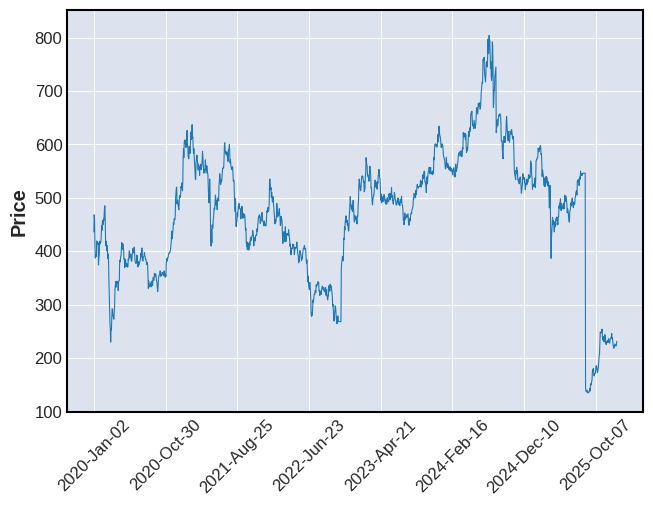

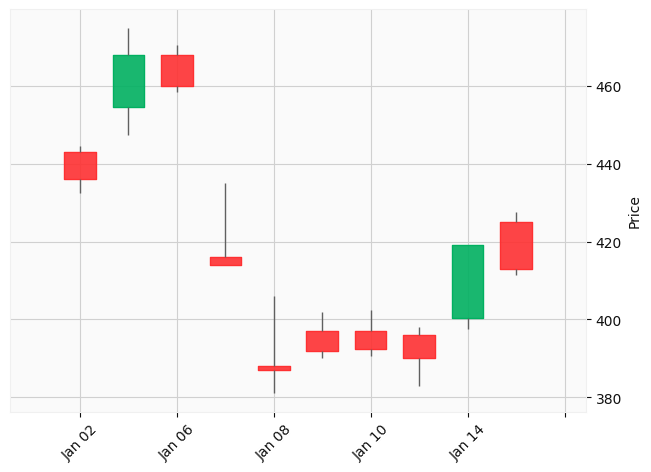

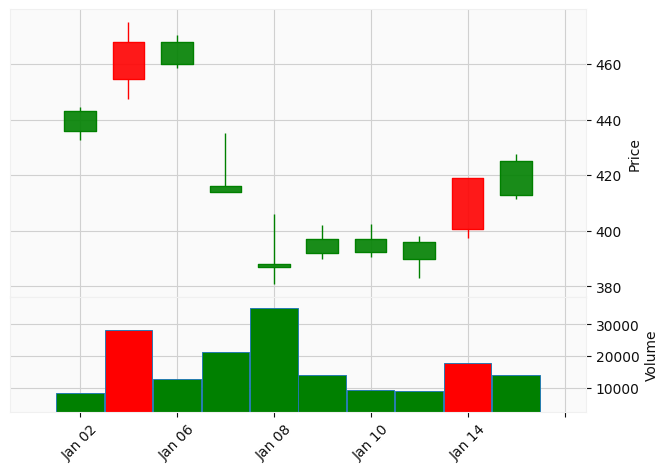

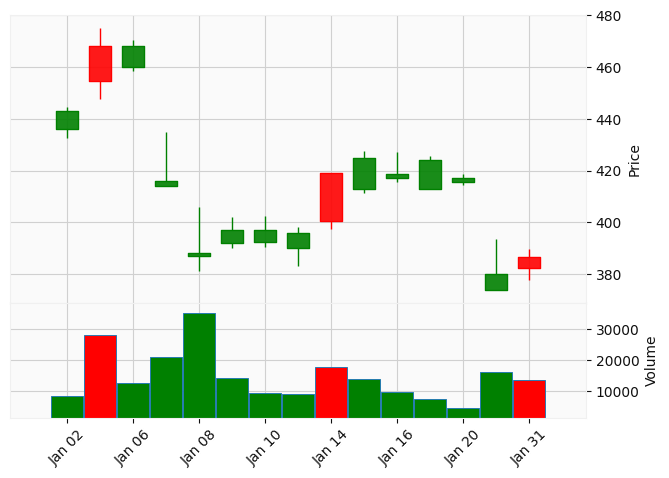

In [7]:
import matplotlib.pyplot as plt # Python用來進行基本繪圖的套件
# !pip install mplfinance

import mplfinance as mpf

mpf.plot(stock.iloc[:, 0:5], type='line') # 繪製曲線圖
mpf.plot(stock.iloc[0:10, :5], type='candle', style='yahoo') # 繪製美國版本的K線圖(綠漲紅跌)

# 將K線圖的顏色改成紅漲綠跌
mcolor = mpf.make_marketcolors(up='r', down='g', inherit=True)
# 將改好的K線圖顏色套用到yahoo裡面
mstyle = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mcolor)

# 用iloc來選取欄位
mpf.plot(stock.iloc[:10, :], type='candle', style=mstyle, volume=True)
# 用loc來選取欄位
mpf.plot(stock.loc[:'2020-01-31', :], type='candle', style=mstyle, volume=True)


#### 🖊️ 隨堂練習 4-1

1. 將時間區段改為 `'2023-01-01':'2023-12-31'`，畫出 2023 年的 K 線圖，觀察走勢差異。
2. 試試 `type='ohlc'`，與 `'candle'` 有何不同？
3. 將 `up='r', down='g'` 改成其他顏色（如 `up='red', down='blue'`），觀察效果。
4. 嘗試只擷取最近三個月的資料並繪圖，切片語法要怎麼寫？

---

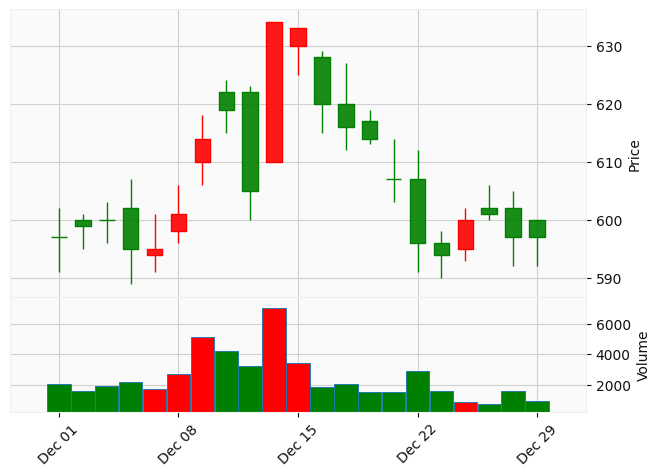

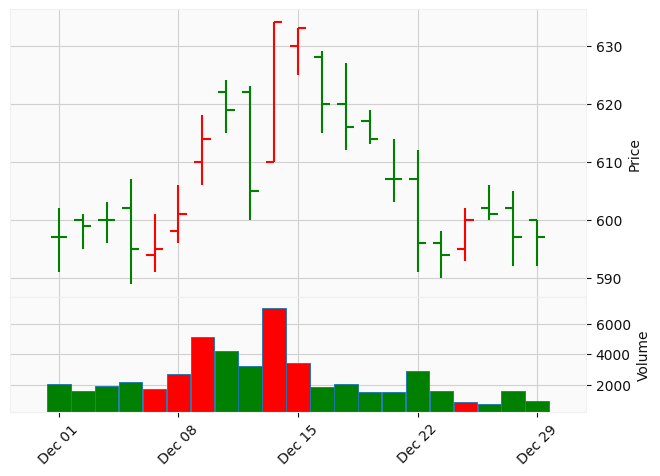

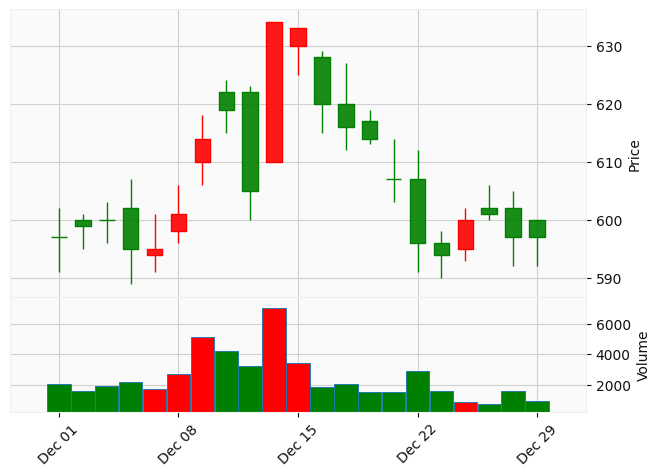

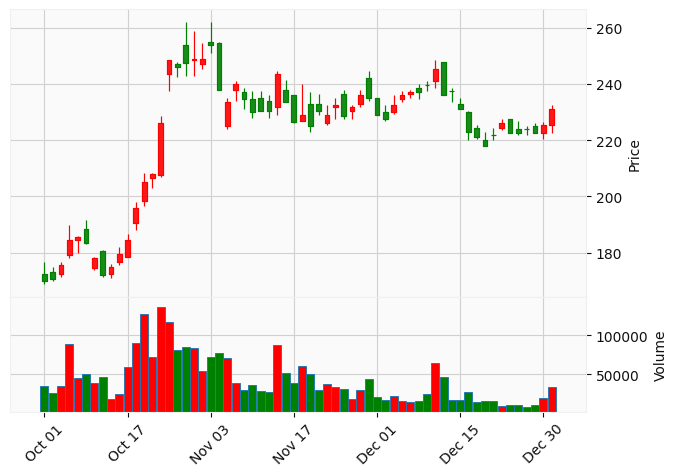

In [8]:
mpf.plot(stock.loc['2023-12-01':'2023-12-31', :], type='candle', style=mstyle, volume=True)
mpf.plot(stock.loc['2023-12-01':'2023-12-31', :], type='ohlc', style=mstyle, volume=True)

# mcolor = mpf.make_marketcolors(up='red', down='blue', inherit=True)
# # 將改好的K線圖顏色套用到yahoo裡面
# mstyle = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mcolor)

mpf.plot(stock.loc['2023-12-01':'2023-12-31', :], type='candle', style=mstyle, volume=True)
mpf.plot(stock.loc['2025-10-01':'2025-12-31', :], type='candle', style=mstyle, volume=True)

### 真實資料操作與分析_3: 基本回測框架的撰寫

In [9]:
# 讀取資料

stock = pd.read_csv('2327_Final.csv', encoding='utf8')
stock.head()

# 時間格式的變更
# 因為原本用read_csv讀進來的檔案的date會變成字串格式，
# 所以我們要轉換成日期格式才能使用時間切片
stock.index = pd.to_datetime(stock.date) # 利用to_datetime對date進行格式轉換
stock = stock.drop(columns=['date']) # 刪除舊有的字串格式的date
stock
stock['2020-01-01':'2025-12-31'] # 利用時間切片進行資料選取
stock = stock.loc[:] # 這個是利用loc方法進行資料選取
stock

,open,high,low,close,volume
date,,,,,
2000-01-04,38.3,38.8,37.5,37.5,75810
2000-01-05,35.2,37.5,35.2,36.2,55597
2000-01-06,36.2,37.4,35.8,36.4,61787
2000-01-07,36.4,37.4,36.4,36.6,57708
2000-01-10,37.2,38.5,36.8,37.8,61759
...,...,...,...,...,...
2026-06-22,1115.0,1120.0,1040.0,1065.0,62351
2026-06-23,1060.0,1085.0,1020.0,1020.0,46353
2026-06-24,1005.0,1075.0,985.0,1050.0,49108


In [10]:
# 基本回測框架的結構
# 1. 要把想要測試的指標產生出來並放進框架內
# 2. 設定進場條和出場條件
# 3. 測試報酬率和交易次數好不好

position = 0 # 代表部位的狀態
trade = pd.DataFrame() # 主要用儲存交易的狀態

for i in range(len(stock)-1):
  c_time = stock.index[i] # 股價的時間
  c_high = stock.loc[c_time, 'high'] # 股價的最高價
  c_low = stock.loc[c_time, 'low'] # 股價的最低價
  c_close = stock.loc[c_time, 'close'] # 股價的收盤價
  c_open = stock.loc[c_time, 'open'] # 股價的開盤價

  n_time = stock.index[i+1] # 隔天的日期
  n_open = stock.loc[n_time, 'open'] # 隔天的開盤價

  # 進場條件
  if position == 0: # 進場的部位如果是0的話，就是沒有持有股票
    if c_close > c_open: # 當天的收盤價大於當天的開盤價
      position = 1 # 部位設成1，代表有股票在手上
      order_i = i # 訂單編號
      order_time = n_time # 隔天的開盤時間
      order_price = n_open # 隔天的開盤價
      order_unit = 1 # 購買1張

  elif position == 1: # 進場的部位如果是1的話，就是有持有股票
    if c_close < c_open: # 當天的收盤價小於當天的開盤價
      position = 0 # 部位設成，代表股票出脫
      cover_time = n_time # 隔天的開盤時間
      cover_price = n_open # 隔天的開盤價

      # 簡化交易紀錄的程式
      # 先用Series儲存買進時間和買進價格和賣出時間和賣出價格
      s1 = pd.Series(['2327', 'Buy', order_time, order_price,
              cover_time, cover_price, order_unit])
      # 將Series s1轉成DataFrame並使用轉置將DataFrame s1轉成1行
      # 然後再使用concat進行合併的動作
      trade = pd.concat([trade, s1.to_frame().T], ignore_index=True)
trade


,0,1,2,3,4,5,6
0,2327,Buy,2000-01-06 00:00:00,36.2,2000-01-12 00:00:00,39.2,1
1,2327,Buy,2000-01-13 00:00:00,42.4,2000-01-15 00:00:00,41.0,1
2,2327,Buy,2000-01-17 00:00:00,42.0,2000-01-18 00:00:00,41.7,1
3,2327,Buy,2000-01-21 00:00:00,42.0,2000-01-26 00:00:00,44.0,1
4,2327,Buy,2000-01-31 00:00:00,42.6,2000-02-01 00:00:00,42.8,1
...,...,...,...,...,...,...,...
1526,2327,Buy,2026-05-28 00:00:00,709.0,2026-06-01 00:00:00,765.0,1
1527,2327,Buy,2026-06-02 00:00:00,771.0,2026-06-05 00:00:00,708.0,1
1528,2327,Buy,2026-06-08 00:00:00,693.0,2026-06-11 00:00:00,850.0,1
1529,2327,Buy,2026-06-16 00:00:00,970.0,2026-06-17 00:00:00,936.0,1


#### 🖊️ 隨堂練習 4-2
1. 讀取玉山金(2884) 2015 年5 月1 日至2020 年12 月31 日的交易資料
2. 繪製玉山金(2884) 2023 年8 月1 日至2023 年8 月31 日的前14 日之曲線圖和K 線圖(紅漲綠跌及成交量)
3. 請依據下列進出場條件來計算玉山金(2884) 2010 年8 月1 日至2020 年12 月31 日的進出場點


*   進場條件：收盤價大於開盤價並且開盤價減最低價要大於2 倍的收盤價減開盤價
* 出場條件：當日收盤價大於開盤價  



In [11]:
# 讀取檔案
stock = pd.read_csv('2884.csv', encoding='big5')
stock.head(20)
stock.tail(20)

# 欄位的更名
stock = stock.rename(columns={'證券代碼':'coid', '簡稱':'name', '年月日':'date',
            '開盤價(元)':'open', '最高價(元)':'high', '最低價(元)':'low',
            '收盤價(元)':'close', '成交量(千股)':'volume'})
stock

# 欄位的刪除
stock = stock.drop(columns=['coid', 'name'])
stock

# 時間格式的變更
stock['date'] = pd.to_datetime(stock['date'], format='%Y%m%d')
stock

# 將日期設為索引
stock = stock.set_index('date')
stock.head()

stock.to_csv('2884_Final.csv', encoding='utf8')
stock

,open,high,low,close,volume
date,,,,,
2002-01-28,14.30,14.30,12.60,13.10,23218
2002-01-29,13.10,13.50,13.10,13.40,16473
2002-01-30,13.30,13.40,13.25,13.35,3575
2002-01-31,13.40,13.60,13.30,13.50,3855
2002-02-01,13.65,13.70,13.50,13.60,4594
...,...,...,...,...,...
2026-06-22,36.00,36.60,35.70,35.80,106058
2026-06-23,35.80,36.35,35.55,35.80,56291
2026-06-24,35.30,35.50,35.00,35.00,66780


In [12]:
# 讀取資料

stock = pd.read_csv('2884_Final.csv', encoding='utf8')
stock.head()

# 時間格式的變更
# 因為原本用read_csv讀進來的檔案的date會變成字串格式，
# 所以我們要轉換成日期格式才能使用時間切片
stock.index = pd.to_datetime(stock.date) # 利用to_datetime對date進行格式轉換
stock = stock.drop(columns=['date']) # 刪除舊有的字串格式的date
stock
stock['2020-01-01':'2025-12-31'] # 利用時間切片進行資料選取
stock = stock.loc['2015-05-01':'2020-12-31'] # 這個是利用loc方法進行資料選取
stock

,open,high,low,close,volume
date,,,,,
2015-05-04,21.20,21.40,20.95,21.20,28059
2015-05-05,21.20,21.30,21.05,21.25,20553
2015-05-06,21.10,21.10,20.90,20.90,18292
2015-05-07,20.90,20.90,20.45,20.45,19449
2015-05-08,20.50,20.75,20.50,20.50,8701
...,...,...,...,...,...
2020-12-25,25.00,25.10,24.95,25.00,12207
2020-12-28,25.00,25.00,24.90,24.95,14644
2020-12-29,24.95,25.00,24.90,25.00,13939


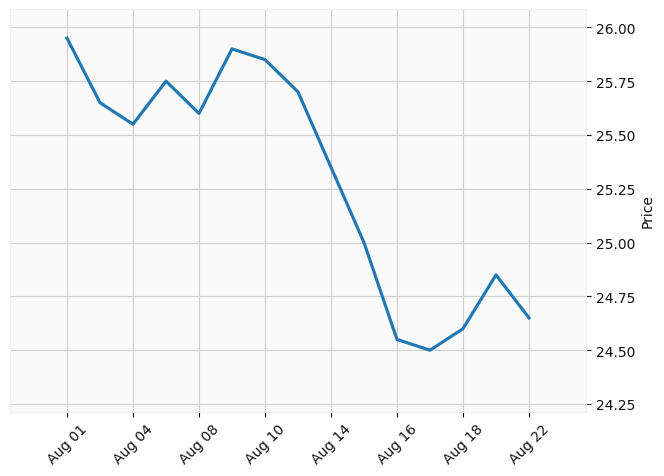

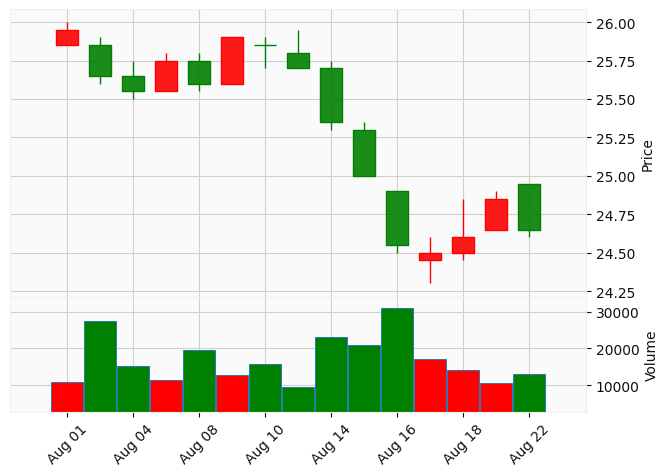

In [13]:
# 讀取資料

stock = pd.read_csv('2884_Final.csv', encoding='utf8')
stock.head()

# 時間格式的變更
# 因為原本用read_csv讀進來的檔案的date會變成字串格式，
# 所以我們要轉換成日期格式才能使用時間切片
stock.index = pd.to_datetime(stock.date) # 利用to_datetime對date進行格式轉換
stock = stock.drop(columns=['date']) # 刪除舊有的字串格式的date
stock
stock['2020-01-01':'2025-12-31'] # 利用時間切片進行資料選取
stock = stock.loc['2023-08-01':'2023-8-31'] # 這個是利用loc方法進行資料選取
stock

mpf.plot(stock.iloc[:15, :], type='line', style=mstyle, volume=False)
mpf.plot(stock.iloc[:15, :], type='candle', style=mstyle, volume=True)

In [14]:
# 讀取資料

stock = pd.read_csv('2884_Final.csv', encoding='utf8')
stock.head()

# 時間格式的變更
# 因為原本用read_csv讀進來的檔案的date會變成字串格式，
# 所以我們要轉換成日期格式才能使用時間切片
stock.index = pd.to_datetime(stock.date) # 利用to_datetime對date進行格式轉換
stock = stock.drop(columns=['date']) # 刪除舊有的字串格式的date
stock
stock['2020-01-01':'2025-12-31'] # 利用時間切片進行資料選取
stock = stock.loc['2010-08-01':'2020-12-31'] # 這個是利用loc方法進行資料選取
stock

# 基本回測框架的結構
# 1. 要把想要測試的指標產生出來並放進框架內
# 2. 設定進場條和出場條件
# 3. 測試報酬率和交易次數好不好

position = 0 # 代表部位的狀態
trade = pd.DataFrame() # 主要用儲存交易的狀態

for i in range(len(stock)-1):
  c_time = stock.index[i] # 股價的時間
  c_high = stock.loc[c_time, 'high'] # 股價的最高價
  c_low = stock.loc[c_time, 'low'] # 股價的最低價
  c_close = stock.loc[c_time, 'close'] # 股價的收盤價
  c_open = stock.loc[c_time, 'open'] # 股價的開盤價

  n_time = stock.index[i+1] # 隔天的日期
  n_open = stock.loc[n_time, 'open'] # 隔天的開盤價

  # 進場條件
  if position == 0: # 進場的部位如果是0的話，就是沒有持有股票
    if c_close > c_open and (c_open - c_low) > 2 * (c_close - c_open): # 當天的收盤價大於當天的開盤價
      position = 1 # 部位設成1，代表有股票在手上
      order_i = i # 訂單編號
      order_time = n_time # 隔天的開盤時間
      order_price = n_open # 隔天的開盤價
      order_unit = 1 # 購買1張

  # 出場條件
  elif position == 1: # 進場的部位如果是1的話，就是有持有股票
    if c_close > c_open: # 當天的收盤價小於當天的開盤價
      position = 0 # 部位設成，代表股票出脫
      cover_time = n_time # 隔天的開盤時間
      cover_price = n_open # 隔天的開盤價

      # 簡化交易紀錄的程式
      # 先用Series儲存買進時間和買進價格和賣出時間和賣出價格
      s1 = pd.Series(['2327', 'Buy', order_time, order_price,
              cover_time, cover_price, order_unit])
      # 將Series s1轉成DataFrame並使用轉置將DataFrame s1轉成1行
      # 然後再使用concat進行合併的動作
      trade = pd.concat([trade, s1.to_frame().T], ignore_index=True)
trade


,0,1,2,3,4,5,6
0,2327,Buy,2010-08-13 00:00:00,15.1,2010-08-16 00:00:00,15.05,1
1,2327,Buy,2010-09-30 00:00:00,16.3,2010-10-07 00:00:00,16.3,1
2,2327,Buy,2010-11-10 00:00:00,16.25,2010-11-15 00:00:00,16.25,1
3,2327,Buy,2010-12-06 00:00:00,17.65,2010-12-07 00:00:00,17.8,1
4,2327,Buy,2010-12-08 00:00:00,17.85,2010-12-10 00:00:00,18.25,1
...,...,...,...,...,...,...,...
83,2327,Buy,2020-05-07 00:00:00,26.85,2020-05-14 00:00:00,27.05,1
84,2327,Buy,2020-07-13 00:00:00,28.5,2020-07-14 00:00:00,29.0,1
85,2327,Buy,2020-10-13 00:00:00,25.3,2020-10-23 00:00:00,24.8,1
86,2327,Buy,2020-11-10 00:00:00,25.55,2020-11-11 00:00:00,25.9,1


## 真實資料操作與分析_4: ChartTrade() — 進出場標記圖

`ChartTrade()` 函數將 `trade` 的進出場日期對應到 K 線圖上：
- **橘紅色 ▲ 三角形**：進場點
- **綠色 ▼ 三角形**：出場點

函數參數：

| 參數 | 說明 |
|---|---|
| `stock` | 含 OHLCV 的 DataFrame |
| `trade` | 交易紀錄 DataFrame（預設空白） |
| `addp` | 額外加入的 addplot 物件列表 |
| `v_enble` | 是否顯示成交量（預留參數） |


In [15]:
# 繪製進出場點至K線圖上

def ChartTrade(stock, trade=pd.DataFrame(), addp=[], v_enable=True):
  # 複製addp，避免直接修改物件，若不複製，多次的函數呼叫可能會影響addp的內容
  addp = addp.copy()
  # 複製stock，避免後續進行欄位合併的動作時影響到原始的stock內容
  stock1 = stock.copy()

  # 只有當trade裡面有交易紀錄時，才會畫標記點
  if trade.shape[0] > 0:
    # 取出交易紀錄的進場日期與進場價格
    buy_order_trade = trade[[2, 3]]
    # 避免畫圖的時候出現警告訊息
    buy_order_trade = buy_order_trade.copy()
    # 將進場日期強制轉換為日期的格式
    buy_order_trade[2] = pd.to_datetime(buy_order_trade[2])
    # 把進場日期設為索引
    buy_order_trade = buy_order_trade.set_index(2)
    # 把欄位名稱改成有意義的名稱
    buy_order_trade.columns = ['buy_order']
    # 去除重複的資料
    buy_order_trade = buy_order_trade.drop_duplicates()

    buy_cover_trade = trade[[4, 5]]
    buy_cover_trade = buy_cover_trade.copy()
    buy_cover_trade[4] = pd.to_datetime(buy_cover_trade[4])
    buy_cover_trade = buy_cover_trade.set_index(4)
    buy_cover_trade.columns = ['buy_cover']
    buy_cover_trade = buy_cover_trade.drop_duplicates()

    # 合併三張表，用axis=1，代表左右合併並依日期來自動對齊
    stock1 = pd.concat([stock1, buy_order_trade, buy_cover_trade], axis=1)

    # 建立進場的標記點(橘紅色，向上的三角形)
    addp.append(mpf.make_addplot(stock1['buy_order'], type='scatter', color='#FF4500',
                  marker='^', markersize=50))
    # 建立出場的標記點(綠色，向下的三角形)
    addp.append(mpf.make_addplot(stock1['buy_cover'], type='scatter', color='#16982B',
                  marker='v', markersize=50))

    # 設定台灣風格的K線圖
    mcolor = mpf.make_marketcolors(up='r', down='g', inherit=True)
    mstyle = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mcolor)

    # 以yahoo風格為基礎，套用上面自訂的漲跌顏色
    mpf.plot(stock1, addplot=addp, type='candle', style=mstyle, volume=True)

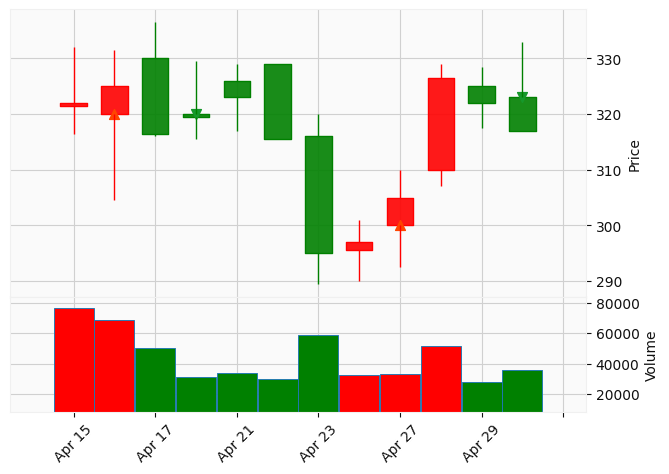

In [16]:
# 讀取資料

stock = pd.read_csv('2327_Final.csv', encoding='utf8')
stock.head()

# 時間格式的變更
# 因為原本用read_csv讀進來的檔案的date會變成字串格式，
# 所以我們要轉換成日期格式才能使用時間切片
stock.index = pd.to_datetime(stock.date) # 利用to_datetime對date進行格式轉換
stock = stock.drop(columns=['date']) # 刪除舊有的字串格式的date
stock
# stock['2020-01-01':'2025-12-31'] # 利用時間切片進行資料選取
stock = stock.loc['2026-04-15':'2026-04-30'] # 這個是利用loc方法進行資料選取
stock

# 基本回測框架的結構
# 1. 要把想要測試的指標產生出來並放進框架內
# 2. 設定進場條和出場條件
# 3. 測試報酬率和交易次數好不好

position = 0 # 代表部位的狀態
trade = pd.DataFrame() # 主要用儲存交易的狀態

for i in range(len(stock)-1):
  c_time = stock.index[i] # 股價的時間
  c_high = stock.loc[c_time, 'high'] # 股價的最高價
  c_low = stock.loc[c_time, 'low'] # 股價的最低價
  c_close = stock.loc[c_time, 'close'] # 股價的收盤價
  c_open = stock.loc[c_time, 'open'] # 股價的開盤價

  n_time = stock.index[i+1] # 隔天的日期
  n_open = stock.loc[n_time, 'open'] # 隔天的開盤價

  # 進場條件
  if position == 0: # 進場的部位如果是0的話，就是沒有持有股票
    if c_close > c_open: # 當天的收盤價大於當天的開盤價
      position = 1 # 部位設成1，代表有股票在手上
      order_i = i # 訂單編號
      order_time = n_time # 隔天的開盤時間
      order_price = n_open # 隔天的開盤價
      order_unit = 1 # 購買1張

  # 出場條件
  elif position == 1: # 進場的部位如果是1的話，就是有持有股票
    if c_close < c_open: # 當天的收盤價小於當天的開盤價
      position = 0 # 部位設成，代表股票出脫
      cover_time = n_time # 隔天的開盤時間
      cover_price = n_open # 隔天的開盤價

      # 簡化交易紀錄的程式
      # 先用Series儲存買進時間和買進價格和賣出時間和賣出價格
      s1 = pd.Series(['2327', 'Buy', order_time, order_price,
              cover_time, cover_price, order_unit])
      # 將Series s1轉成DataFrame並使用轉置將DataFrame s1轉成1行
      # 然後再使用concat進行合併的動作
      trade = pd.concat([trade, s1.to_frame().T], ignore_index=True)
# trade
ChartTrade(stock[:], trade[:])

#### 🖊️ 隨堂練習 4-3
1. 將資料區段改為 `'2024-01-01':'2024-12-31'`，重新執行回測並呼叫 `ChartTrade()`，
   觀察進出場點的分布情形。
2. 修改進場條件為「當日最高價創近 5 日新高（`c_high >= stock['High'].iloc[i-4:i+1].max()`）」，
   出場條件維持原本的收黑，觀察結果有何不同？

---

In [17]:
# 讀取資料

stock = pd.read_csv('2327_Final.csv', encoding='utf8')
stock.head()

# 時間格式的變更
# 因為原本用read_csv讀進來的檔案的date會變成字串格式，
# 所以我們要轉換成日期格式才能使用時間切片
stock.index = pd.to_datetime(stock.date) # 利用to_datetime對date進行格式轉換
stock = stock.drop(columns=['date']) # 刪除舊有的字串格式的date
stock
# stock['2020-01-01':'2025-12-31'] # 利用時間切片進行資料選取
stock = stock.loc['2024-01-01':'2024-12-31'] # 這個是利用loc方法進行資料選取
stock

,open,high,low,close,volume
date,,,,,
2024-01-02,601.0,605.0,587.0,587.0,2194
2024-01-03,581.0,585.0,575.0,578.0,2127
2024-01-04,588.0,590.0,575.0,577.0,1294
2024-01-05,580.0,580.0,572.0,572.0,1193
2024-01-08,576.0,581.0,570.0,572.0,1157
...,...,...,...,...,...
2024-12-25,532.0,535.0,530.0,533.0,775
2024-12-26,536.0,547.0,536.0,543.0,3163
2024-12-27,541.0,543.0,538.0,539.0,1095


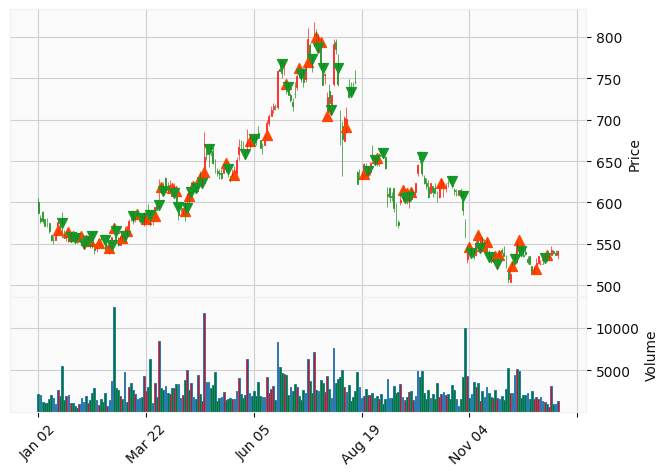

In [18]:
# 基本回測框架的結構
# 1. 要把想要測試的指標產生出來並放進框架內
# 2. 設定進場條和出場條件
# 3. 測試報酬率和交易次數好不好

position = 0 # 代表部位的狀態
trade = pd.DataFrame() # 主要用儲存交易的狀態

for i in range(len(stock)-1):
  c_time = stock.index[i] # 股價的時間
  c_high = stock.loc[c_time, 'high'] # 股價的最高價
  c_low = stock.loc[c_time, 'low'] # 股價的最低價
  c_close = stock.loc[c_time, 'close'] # 股價的收盤價
  c_open = stock.loc[c_time, 'open'] # 股價的開盤價

  n_time = stock.index[i+1] # 隔天的日期
  n_open = stock.loc[n_time, 'open'] # 隔天的開盤價

  # 進場條件
  if position == 0: # 進場的部位如果是0的話，就是沒有持有股票
    if c_close > c_open: # 當天的收盤價大於當天的開盤價
      position = 1 # 部位設成1，代表有股票在手上
      order_i = i # 訂單編號
      order_time = n_time # 隔天的開盤時間
      order_price = n_open # 隔天的開盤價
      order_unit = 1 # 購買1張

  # 出場條件
  elif position == 1: # 進場的部位如果是1的話，就是有持有股票
    if c_close < c_open: # 當天的收盤價小於當天的開盤價
      position = 0 # 部位設成，代表股票出脫
      cover_time = n_time # 隔天的開盤時間
      cover_price = n_open # 隔天的開盤價

      # 簡化交易紀錄的程式
      # 先用Series儲存買進時間和買進價格和賣出時間和賣出價格
      s1 = pd.Series(['2327', 'Buy', order_time, order_price,
              cover_time, cover_price, order_unit])
      # 將Series s1轉成DataFrame並使用轉置將DataFrame s1轉成1行
      # 然後再使用concat進行合併的動作
      trade = pd.concat([trade, s1.to_frame().T], ignore_index=True)
# trade
ChartTrade(stock[:], trade[:])

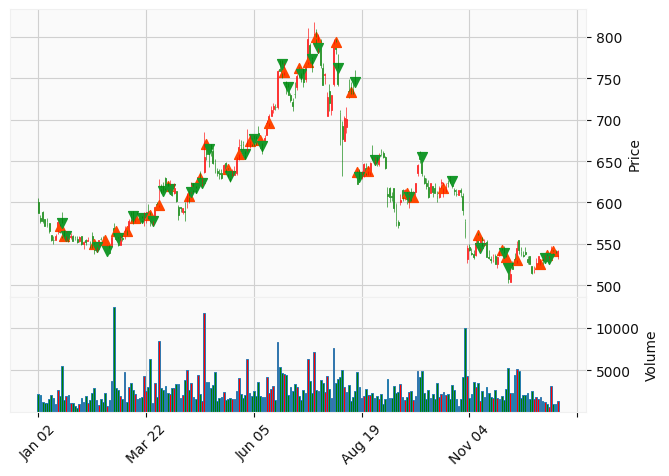

In [19]:
# 基本回測框架的結構
# 1. 要把想要測試的指標產生出來並放進框架內
# 2. 設定進場條和出場條件
# 3. 測試報酬率和交易次數好不好

position = 0 # 代表部位的狀態
trade = pd.DataFrame() # 主要用儲存交易的狀態

for i in range(len(stock)-1):
  c_time = stock.index[i] # 股價的時間
  c_high = stock.loc[c_time, 'high'] # 股價的最高價
  c_low = stock.loc[c_time, 'low'] # 股價的最低價
  c_close = stock.loc[c_time, 'close'] # 股價的收盤價
  c_open = stock.loc[c_time, 'open'] # 股價的開盤價

  n_time = stock.index[i+1] # 隔天的日期
  n_open = stock.loc[n_time, 'open'] # 隔天的開盤價

  # 進場條件
  if position == 0: # 進場的部位如果是0的話，就是沒有持有股票
    if c_high >= stock['high'].iloc[i-4:i+1].max(): # 當天的收盤價大於當天的開盤價
      position = 1 # 部位設成1，代表有股票在手上
      order_i = i # 訂單編號
      order_time = n_time # 隔天的開盤時間
      order_price = n_open # 隔天的開盤價
      order_unit = 1 # 購買1張

  # 出場條件
  elif position == 1: # 進場的部位如果是1的話，就是有持有股票
    if c_close < c_open: # 當天的收盤價小於當天的開盤價
      position = 0 # 部位設成，代表股票出脫
      cover_time = n_time # 隔天的開盤時間
      cover_price = n_open # 隔天的開盤價

      # 簡化交易紀錄的程式
      # 先用Series儲存買進時間和買進價格和賣出時間和賣出價格
      s1 = pd.Series(['2327', 'Buy', order_time, order_price,
              cover_time, cover_price, order_unit])
      # 將Series s1轉成DataFrame並使用轉置將DataFrame s1轉成1行
      # 然後再使用concat進行合併的動作
      trade = pd.concat([trade, s1.to_frame().T], ignore_index=True)
trade
ChartTrade(stock[:], trade[:])

### 真實資料操作與分析_5: 製作Performance 績效函數




In [35]:
# 計算交易績效指標的計算

def Performance(trade=pd.DataFrame(), prodtype='Stock'):
  # 防呆機制:若沒有交易紀錄，直接結束函數
  if trade.shape[0] == 0:
    print('沒有交易紀錄')
    return False

  # 將trade物件複製，避免影響原始trade的內容
  trade1 = trade.copy()
  trade1 = trade.sort_values(4)
  trade1 = trade.reset_index(drop=True)

  # 定義交易明細表的欄位
  trade1.columns = ['product', 'bs', 'order_time', 'order_price', 'cover_time',
            'cover_price', 'order_unit']

  # 判斷交易成本的計算
  if prodtype == 'ETF':
    comm_rate = 0.001425 # 交易手續費約0.1425%
    tax_rare = 0.001 # 證交稅約0.1%(只有賣出股票的時候才會扣)
  elif prodtype == 'Stock':
    comm_rate = 0.001425 # 交易手續費約0.1425%
    tax_rare = 0.003 # 證交稅約0.3%(只有賣出股票的時候才會扣)
  else:
    return False

  # 計算每筆交易的成本與損益
  # 計算買進股票的手續費
  fee_buy = trade1['order_price'] * trade1['order_unit'] * comm_rate

  # 計算賣出股票的手續費
  fee_sell = trade1['cover_price'] * trade1['order_unit'] * comm_rate

  # 計算賣出股票的稅金
  tax = trade1['cover_price'] * trade1['order_unit'] * tax_rare

  # 買入成本 = 買入價格+買入手續費
  cost_basis = trade1['order_price'] * trade1['order_unit'] + fee_buy

  # 賣出的淨利潤
  net_profit = (trade1['cover_price'] * trade1['order_unit']) - \
          (trade1['order_price'] * trade1['order_unit']) - fee_buy - \
          fee_sell - tax

  # 計算報酬率:每筆報酬率 = 淨利潤 / 買進成本
  trade1['ret'] = net_profit / cost_basis

  # 總報酬率:代表交易紀錄的報酬率之累加
  print(f'總報酬率:{trade1['ret'].sum():.3f}')

  # 總交易次數
  print(f'交易次數:{trade1.shape[0]}')

  # 平均報酬率:每筆交易的平均獲利/虧損
  print(f'平均報酬率:{trade1['ret'].mean():.3f}')

  # 判斷是否獲利或虧損:將交易紀錄拆分為獲利與虧損
  earn_trade = trade1[trade1['ret'] > 0] # 報酬率>0:獲利的交易
  loss_trade = trade1[trade1['ret'] <= 0] # 報酬率<=0:虧損或打平的交易

  # 防呆機制:若全勝或全敗(無法計算賺賠比),直接結束
  if earn_trade.shape[0] == 0 or loss_trade.shape[0] == 0:
    print('交易資料樣本不足(樣本中要有賺有賠)')
    return False

  # 計算勝率:獲利筆數 / 交易次數
  earn_ratio = earn_trade.shape[0] / trade1.shape[0]
  print(f'勝率%:{earn_ratio:.3f}')

  # 平均獲利:獲利交易的平均報酬率
  avg_earn = earn_trade['ret'].mean()
  print(f'平均獲利:{avg_earn:.3f}')

  # 平均虧損:虧損交易的平均報酬率(負值)
  avg_loss = loss_trade['ret'].mean()
  print(f'平均虧損:{avg_loss:.3f}')

  # 賺賠比:平均獲利 / 平均虧損,然後取絕對值
  # 代表[平均每賺1元，最多虧多少錢], 賺賠比要越大越好(建議 > 1.5)
  odds = abs(avg_earn / avg_loss)
  print(f'賺賠比:{odds:.3f}')

  # 最大連續虧損
  # 邏輯:遇到虧損就進行累乘,遇到獲利就重置為1
  # 目的:衡量連續虧損時,資金最大萎縮的幅度
  tmp_accloss = 1 # 暫存當前的連續虧損的累乘值
  max_accloss = 1 # 紀錄歷史最大的連續虧損值

  for ret in trade1['ret'].values:
    if ret <= 0:
      tmp_accloss = tmp_accloss * ret # 連續虧損:持續進行累乘
      max_accloss = min(max_accloss, tmp_accloss) # 取最小值(最大虧損)
    else:
      tmp_accloss = 1 # 遇到獲利的狀態,重置為1,以便重新計算
  print(f'最大連續虧損:{max_accloss:.3f}')

  # 計算累積報酬率:目的是為了畫出資金曲線圖
  # cumprod():累積乘積,模擬每筆交易後資金的複利狀態
  trade1['acc_ret'] = (1+trade1['ret']).cumprod()

  # 計算最大資金回落
  # 步驟1:計算截至目前為止的歷史最高的累積報酬率
  trade1['acc_max_cap'] = trade1['acc_ret'].cummax()

  # 步驟2:當前的累積報酬率 / 歷史最高的累積報酬率 = 目前從最高點回落的比例
  trade1['dd'] = trade1['acc_ret'] / trade1['acc_max_cap']

  # 步驟3:標記每次創新高的點(在圖上顯示紅點)
  # 當trade1['acc_ret'] == trade1['acc_max_cap']時,代表該筆交易後資金創歷史新高
  trade1.loc[trade1['acc_ret'] == trade1['acc_max_cap'], 'new_high'] = trade1['acc_ret']

  # MDD = 1 - dd的最小值(也就是回落最深的那個點距離最高點的幅度)
  print(f'最大資金回落;{(1-trade1['dd'].min()):.3f}')

  # 繪製資金曲線圖
  ax = plt.subplot(111) # 建立子圖

  # 藍線(Profit):累積報酬率曲線，代表資金成長的走勢
  ax.plot(trade1['acc_ret'], 'b-', label='Profit')

  # 綠線(MDD):每筆交易相對歷史高點的回落比例
  ax.plot(trade1['dd'], '-', color='g', label='MDD')

  # 紅點:每次累積報酬率創歷史新高的交易點
  ax.plot(trade1['new_high'], 'o', color='r', label='Equity high')

  plt.legend() # 顯示圖例
  plt.show() # 顯示圖形


總報酬率:-0.099
交易次數:55
平均報酬率:-0.002
勝率%:0.327
平均獲利:0.025
平均虧損:-0.015
賺賠比:1.682
最大連續虧損:-0.031
最大資金回落;0.155


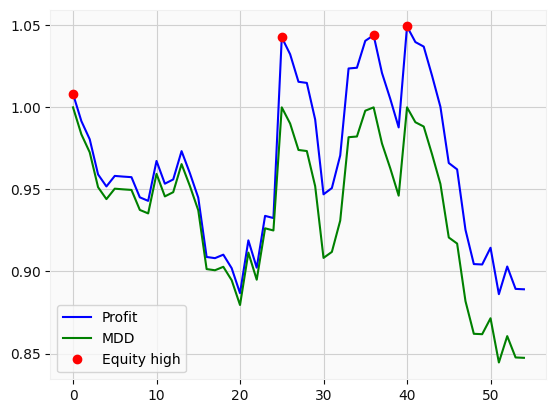

In [38]:
# 基本回測框架的結構
# 1. 要把想要測試的指標產生出來並放進框架內
# 2. 設定進場條和出場條件
# 3. 測試報酬率和交易次數好不好

position = 0 # 代表部位的狀態
trade = pd.DataFrame() # 主要用儲存交易的狀態

for i in range(len(stock)-1):
  c_time = stock.index[i] # 股價的時間
  c_high = stock.loc[c_time, 'high'] # 股價的最高價
  c_low = stock.loc[c_time, 'low'] # 股價的最低價
  c_close = stock.loc[c_time, 'close'] # 股價的收盤價
  c_open = stock.loc[c_time, 'open'] # 股價的開盤價

  n_time = stock.index[i+1] # 隔天的日期
  n_open = stock.loc[n_time, 'open'] # 隔天的開盤價

  # 進場條件
  if position == 0: # 進場的部位如果是0的話，就是沒有持有股票
    if c_close > c_open: # 當天的收盤價大於當天的開盤價
      position = 1 # 部位設成1，代表有股票在手上
      order_i = i # 訂單編號
      order_time = n_time # 隔天的開盤時間
      order_price = n_open # 隔天的開盤價
      order_unit = 1 # 購買1張

  # 出場條件
  elif position == 1: # 進場的部位如果是1的話，就是有持有股票
    if c_close < c_open: # 當天的收盤價小於當天的開盤價
      position = 0 # 部位設成，代表股票出脫
      cover_time = n_time # 隔天的開盤時間
      cover_price = n_open # 隔天的開盤價

      # 簡化交易紀錄的程式
      # 先用Series儲存買進時間和買進價格和賣出時間和賣出價格
      s1 = pd.Series(['2327', 'Buy', order_time, order_price,
              cover_time, cover_price, order_unit])
      # 將Series s1轉成DataFrame並使用轉置將DataFrame s1轉成1行
      # 然後再使用concat進行合併的動作
      trade = pd.concat([trade, s1.to_frame().T], ignore_index=True)
# trade
# ChartTrade(stock[:], trade[:])
Performance(trade, 'Stock')

## 績效指標說明

| 指標 | 說明 | 觀察重點 |
|---|---|---|
| 總報酬率 | 所有交易報酬率加總 | 越高越好 |
| 交易次數 | 完整進出場次數 | 太多→過度交易；太少→樣本不足 |
| 平均報酬率 | 每筆交易平均獲利 | 正值才有意義 |
| 勝率 | 獲利筆數 / 總交易次數 | 勝率高不代表策略好（需搭配賺賠比） |
| 賺賠比 | 平均獲利 / 平均虧損（絕對值） | 一般建議 > 1.5 |
| 最大連續虧損 | 連續虧損的累乘值 | 越接近 0 越危險 |
| 最大資金回落 MDD | 最大高峰到谷底的跌幅 | 越小越好，一般可接受 < 20% |

**資金曲線圖三條線：**
- 🔵 藍線（Profit）：累積報酬率曲線，向上代表獲利
- 🟢 綠線（MDD）：回落比例，在 1.0 下方代表從高點回落
- 🔴 紅點（Equity High）：每次創新高的交易點

#### 🖊️ 隨堂練習 4-4
1. 請依據下列進出場條件來計算金像電子(2368) 2010 年 8 月 1 日至 2020 年 12 月 31 日的進出場點

   **進場條件：** 當日收盤價大於前一日最高價，並且當日成交量大於前一日成交量的 1.5 倍

   **出場條件：** 當日收盤價小於前一日收盤價

2. 使用上述的策略，將金像電子(2368) 2010 年 8 月 1 日至 2020 年 12 月 31 日的進出場點繪製於 K 線圖內

3. 使用上述的策略，將金像電子(2368) 2010 年 8 月 1 日至 2020 年 12 月 31 日的進出場點計算總報酬率、交易次數、平均報酬率、勝率、平均獲利、平均虧損、賺賠比、最大連續虧損、最大資金回落和資金曲線圖

In [ ]:
import pandas as pd
import numpy as np

# 讀取檔案
stock = pd.read_csv('2368.csv', encoding='big5')
stock.head(20)
stock.tail(20)

# 欄位的更名
stock = stock.rename(columns={'證券代碼':'coid', '簡稱':'name', '年月日':'date',
            '開盤價(元)':'open', '最高價(元)':'high', '最低價(元)':'low',
            '收盤價(元)':'close', '成交量(千股)':'volume'})
stock

# 欄位的刪除
stock = stock.drop(columns=['coid', 'name'])
stock

# 時間格式的變更
stock['date'] = pd.to_datetime(stock['date'], format='%Y%m%d')
stock

# 將日期設為索引
stock = stock.set_index('date')
stock.head()

stock.to_csv('2368_Final.csv', encoding='utf8')
stock

In [ ]:
# 讀取資料

stock = pd.read_csv('2368_Final.csv', encoding='utf8')
stock.head()

# 時間格式的變更
# 因為原本用read_csv讀進來的檔案的date會變成字串格式，
# 所以我們要轉換成日期格式才能使用時間切片
stock.index = pd.to_datetime(stock.date) # 利用to_datetime對date進行格式轉換
stock = stock.drop(columns=['date']) # 刪除舊有的字串格式的date
stock
# stock['2020-01-01':'2025-12-31'] # 利用時間切片進行資料選取
stock = stock.loc['2010-08-01':'2020-12-31'] # 這個是利用loc方法進行資料選取
stock

In [41]:
# 基本回測框架的結構
# 1. 要把想要測試的指標產生出來並放進框架內
# 2. 設定進場條和出場條件
# 3. 測試報酬率和交易次數好不好

position = 0 # 代表部位的狀態
trade = pd.DataFrame() # 主要用儲存交易的狀態

for i in range(len(stock)-1):
  c_time = stock.index[i] # 當天股價的時間
  c_high = stock.loc[c_time, 'high'] # 股價的最高價
  c_low = stock.loc[c_time, 'low'] # 股價的最低價
  c_close = stock.loc[c_time, 'close'] # 股價的收盤價
  c_open = stock.loc[c_time, 'open'] # 股價的開盤價
  c_volume = stock.loc[c_time, 'volume'] # 當天的成交量

  p_time = stock.index[i-1] # 前一天的時間
  p_high = stock.loc[p_time, 'high'] # 前一天的最高價
  p_close = stock.loc[p_time, 'close'] # 前一天的收盤價
  p_volume = stock.loc[p_time, 'volume'] # 前一天的成交量

  n_time = stock.index[i+1] # 隔天的日期
  n_open = stock.loc[n_time, 'open'] # 隔天的開盤價

  # 進場條件
  if position == 0: # 進場的部位如果是0的話，就是沒有持有股票
    if c_close > p_high and c_volume > p_volume * 1.5: # 當天的收盤價大於當天的開盤價
      position = 1 # 部位設成1，代表有股票在手上
      order_i = i # 訂單編號
      order_time = n_time # 隔天的開盤時間
      order_price = n_open # 隔天的開盤價
      order_unit = 1 # 購買1張

  # 出場條件
  elif position == 1: # 進場的部位如果是1的話，就是有持有股票
    if c_close < p_close: # 當天的收盤價小於當天的開盤價
      position = 0 # 部位設成，代表股票出脫
      cover_time = n_time # 隔天的開盤時間
      cover_price = n_open # 隔天的開盤價

      # 簡化交易紀錄的程式
      # 先用Series儲存買進時間和買進價格和賣出時間和賣出價格
      s1 = pd.Series(['2368', 'Buy', order_time, order_price,
              cover_time, cover_price, order_unit])
      # 將Series s1轉成DataFrame並使用轉置將DataFrame s1轉成1行
      # 然後再使用concat進行合併的動作
      trade = pd.concat([trade, s1.to_frame().T], ignore_index=True)
trade
# ChartTrade(stock[:], trade[:])
# Performance(trade, 'Stock')

,0,1,2,3,4,5,6
0,2368,Buy,2010-08-16 00:00:00,11.8,2010-08-17 00:00:00,11.9,1
1,2368,Buy,2010-09-03 00:00:00,10.9,2010-09-08 00:00:00,10.95,1
2,2368,Buy,2010-09-14 00:00:00,11.2,2010-09-16 00:00:00,11.15,1
3,2368,Buy,2010-09-20 00:00:00,11.3,2010-09-21 00:00:00,11.3,1
4,2368,Buy,2010-09-28 00:00:00,11.6,2010-09-29 00:00:00,11.4,1
...,...,...,...,...,...,...,...
248,2368,Buy,2020-10-15 00:00:00,47.35,2020-10-16 00:00:00,46.0,1
249,2368,Buy,2020-10-20 00:00:00,50.8,2020-10-22 00:00:00,49.0,1
250,2368,Buy,2020-11-18 00:00:00,45.45,2020-11-26 00:00:00,50.3,1
251,2368,Buy,2020-12-09 00:00:00,53.0,2020-12-10 00:00:00,52.0,1


/usr/local/lib/python3.12/dist-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


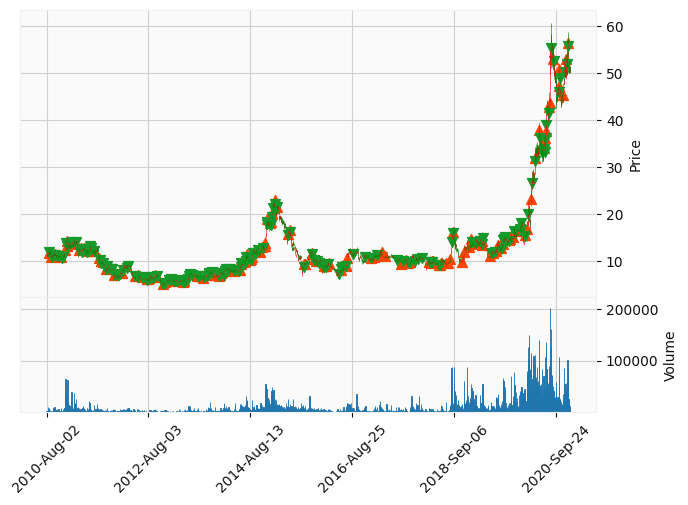

In [42]:
ChartTrade(stock[:], trade[:])

總報酬率:-1.060
交易次數:253
平均報酬率:-0.004
勝率%:0.253
平均獲利:0.046
平均虧損:-0.021
賺賠比:2.174
最大連續虧損:-0.068
最大資金回落;0.825


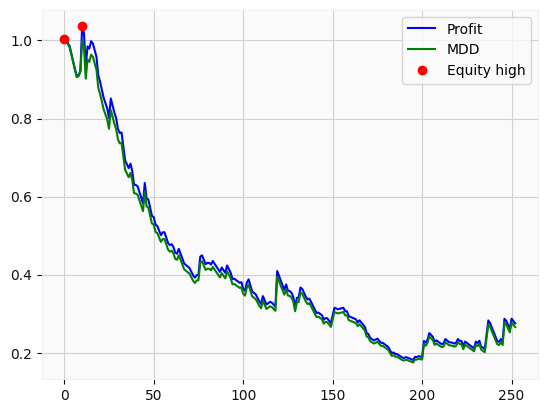

In [43]:
Performance(trade, 'Stock')